### Dataset Characteristics: Breast Cancer Wisconsin (Diagnostic)

*   **Dataset Name**: [Breast Cancer Wisconsin (Diagnostic) Dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).
*   **Dimensions**: 569 instances and 30 feature variables.
*   **Features**: The 30 features are continuous values representing characteristics of cell nuclei computed from digitized images (e.g., radius, texture, perimeter, area, smoothness, etc.). They are grouped into three categories for each characteristic: mean (suffix '1'), standard error (suffix '2'), and worst/largest (suffix '3').
*   **Target**: The target variable is `Diagnosis` with two classes:
    *   **B (Benign)**: 357 instances (62.7%)
    *   **M (Malignant)**: 212 instances (37.3%)
*   **Data Quality**: There are **no missing values** in the features or the target.
*   **Correlations**: The dataset exhibits high multicollinearity among several features (e.g., radius, perimeter, and area are highly correlated, with coefficients > 0.99).

The 10 Base Characteristics
For each cell nucleus, the following ten real-valued features are computed:

1.  **Radius:** Mean of distances from center to points on the perimeter.
2.  **Texture:** Standard deviation of gray-scale values.
3.  **Perimeter:** The total distance around the boundary of the nucleus.
4.  **Area:** The number of pixels within the boundary of the nucleus.
5.  **Smoothness:** Local variation in radius lengths.
6.  **Compactness:** Computed as $\frac{\text{perimeter}^2}{\text{area}} - 1.0$.
7.  **Concavity:** Severity of concave portions of the contour.
8.  **Concave Points:** Number of concave portions of the contour.
9.  **Symmetry:** A measure of the symmetry of the nucleus shape.
10. **Fractal Dimension:** "Coastline approximation" - 1 (a measure of boundary complexity).

For each of the 10 characteristics listed above, three distinct values are calculated, resulting in 30 total feature columns:

* **Mean:** The average value (e.g., `radius_mean`).
* **Standard Error (SE):** The standard error of the value (e.g., `radius_se`).
* **Worst:** The "worst" or largest (mean of the three largest values) value computed (e.g., `radius_worst`).

---

### Statistical Notes
* **Multicollinearity:** The dataset exhibits high multicollinearity.
    * **Geometric Correlations:** Features like **Radius**, **Perimeter**, and **Area** are mathematically related and have correlation coefficients $> 0.99$.
    * **Shape Correlations:** **Compactness**, **Concavity**, and **Concave Points** also tend to show high correlation.

In [139]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.decomposition import (
    PCA,
    KernelPCA
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

from sklearn.model_selection import cross_val_score

import time
import pickle
import os
from ucimlrepo import fetch_ucirepo

RANDOM_STATE = 42

In [140]:
import os
import pickle
from ucimlrepo import fetch_ucirepo

# File paths for saved data
DATA_DIR = "data"
X_FILE = os.path.join(DATA_DIR, "breast_cancer_X.pkl")
y_FILE = os.path.join(DATA_DIR, "breast_cancer_y.pkl")
METADATA_FILE = os.path.join(DATA_DIR, "breast_cancer_metadata.pkl")

# Check if saved files exist
if os.path.exists(X_FILE) and os.path.exists(y_FILE):
    print("Loading dataset from saved files...")
    with open(X_FILE, 'rb') as f:
        X = pickle.load(f)
    with open(y_FILE, 'rb') as f:
        y = pickle.load(f)
    if os.path.exists(METADATA_FILE):
        with open(METADATA_FILE, 'rb') as f:
            metadata_dict = pickle.load(f)
else:
    print("Downloading dataset from UCI repository...")
    # fetch dataset
    breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

    # data (as pandas dataframes)
    X = breast_cancer_wisconsin_diagnostic.data.features
    y = breast_cancer_wisconsin_diagnostic.data.targets

    # Create data directory if it doesn't exist
    os.makedirs(DATA_DIR, exist_ok=True)

    # Save the data
    print("Saving dataset...")
    with open(X_FILE, 'wb') as f:
        pickle.dump(X, f)
    with open(y_FILE, 'wb') as f:
        pickle.dump(y, f)
    with open(METADATA_FILE, 'wb') as f:
        metadata_dict = {
            'metadata': breast_cancer_wisconsin_diagnostic.metadata,
            'variables': breast_cancer_wisconsin_diagnostic.variables
        }
        pickle.dump(metadata_dict, f)

print(f"\nDataset loaded: X shape = {X.shape}, y shape = {y.shape}")

Loading dataset from saved files...

Dataset loaded: X shape = (569, 30), y shape = (569, 1)


In [141]:
print("\nVariable information:")
print(metadata_dict['variables'])


Variable information:
                  name     role         type demographic description units  \
0                   ID       ID  Categorical        None        None  None   
1            Diagnosis   Target  Categorical        None        None  None   
2              radius1  Feature   Continuous        None        None  None   
3             texture1  Feature   Continuous        None        None  None   
4           perimeter1  Feature   Continuous        None        None  None   
5                area1  Feature   Continuous        None        None  None   
6          smoothness1  Feature   Continuous        None        None  None   
7         compactness1  Feature   Continuous        None        None  None   
8           concavity1  Feature   Continuous        None        None  None   
9      concave_points1  Feature   Continuous        None        None  None   
10           symmetry1  Feature   Continuous        None        None  None   
11  fractal_dimension1  Feature   Continu

In [142]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

In [143]:
X.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [144]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Diagnosis  569 non-null    object
dtypes: object(1)
memory usage: 4.6+ KB


In [145]:
y.describe()

,Diagnosis
count,569
unique,2
top,B
freq,357


Randomly selected features (random_state=42):
['concave_points3', 'compactness2', 'area3', 'concave_points2', 'symmetry1']


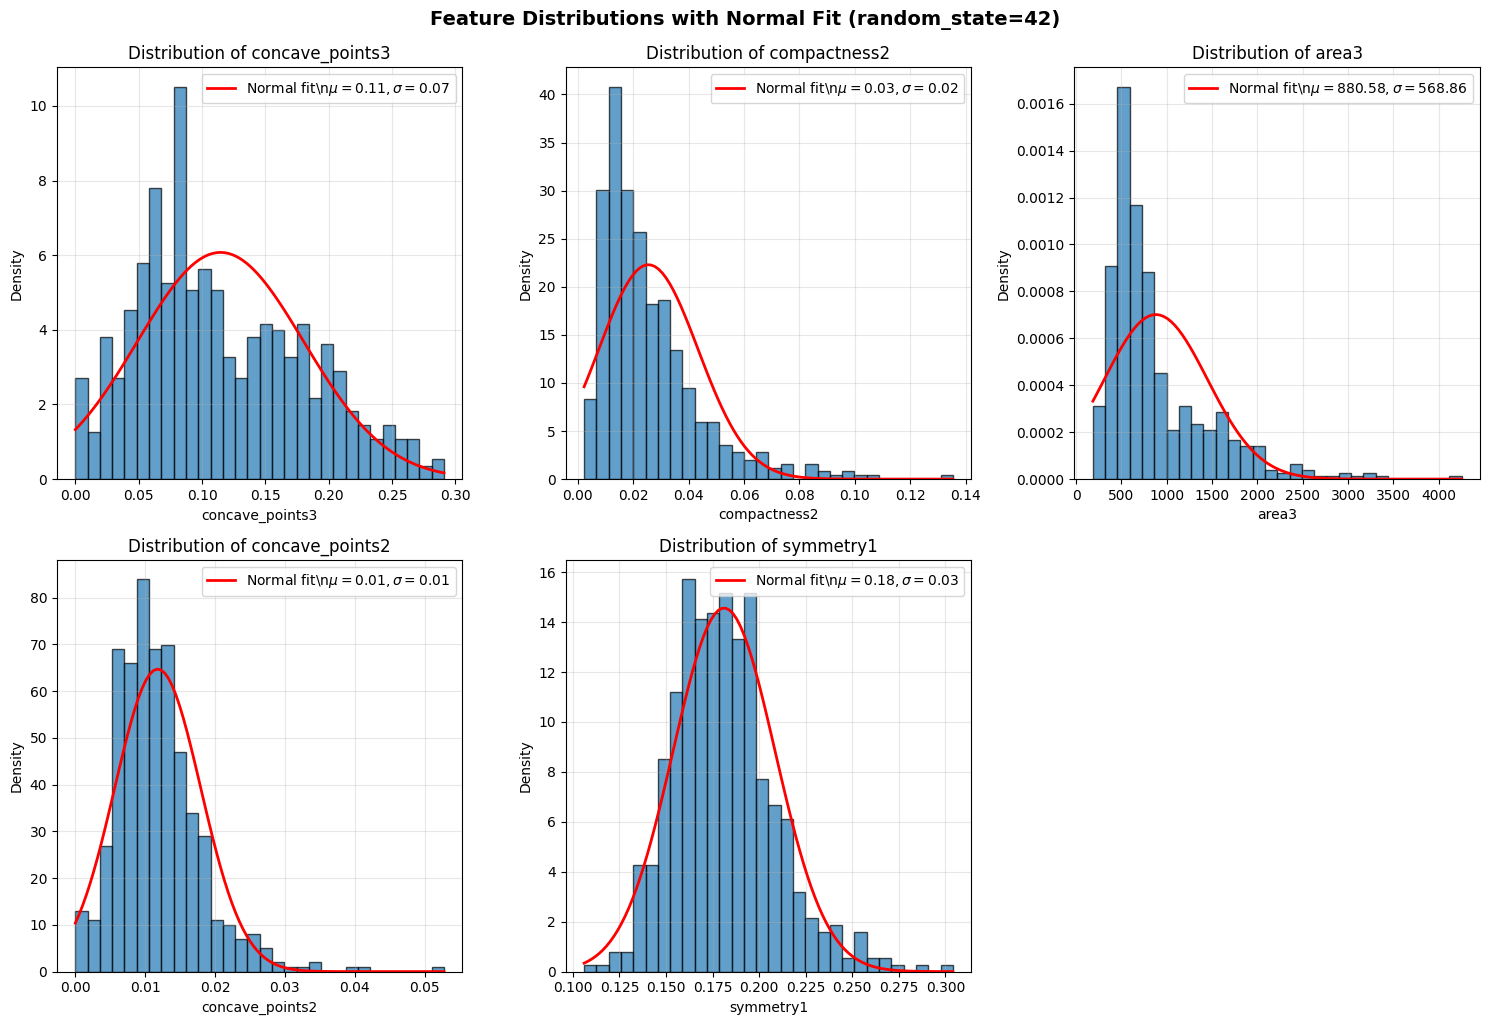

In [146]:
np.random.seed(RANDOM_STATE)

random_features = np.random.choice(X.columns, size=5, replace=False)
print(f"Randomly selected features (random_state={RANDOM_STATE}):")
print(list(random_features))

# Create histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(random_features):
    data = X[feature]

    axes[idx].hist(data, bins=30, edgecolor='black', alpha=0.7, density=True)

    mu, std = norm.fit(data)

    xmin, xmax = data.min(), data.max()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    axes[idx].plot(x, p, 'r', linewidth=2, label=rf'Normal fit\n$\mu={mu:.2f}, \sigma={std:.2f}$')

    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

axes[5].axis('off')

plt.tight_layout()
plt.suptitle(f'Feature Distributions with Normal Fit (random_state={RANDOM_STATE})', y=1.02, fontsize=14, fontweight='bold')
plt.show()

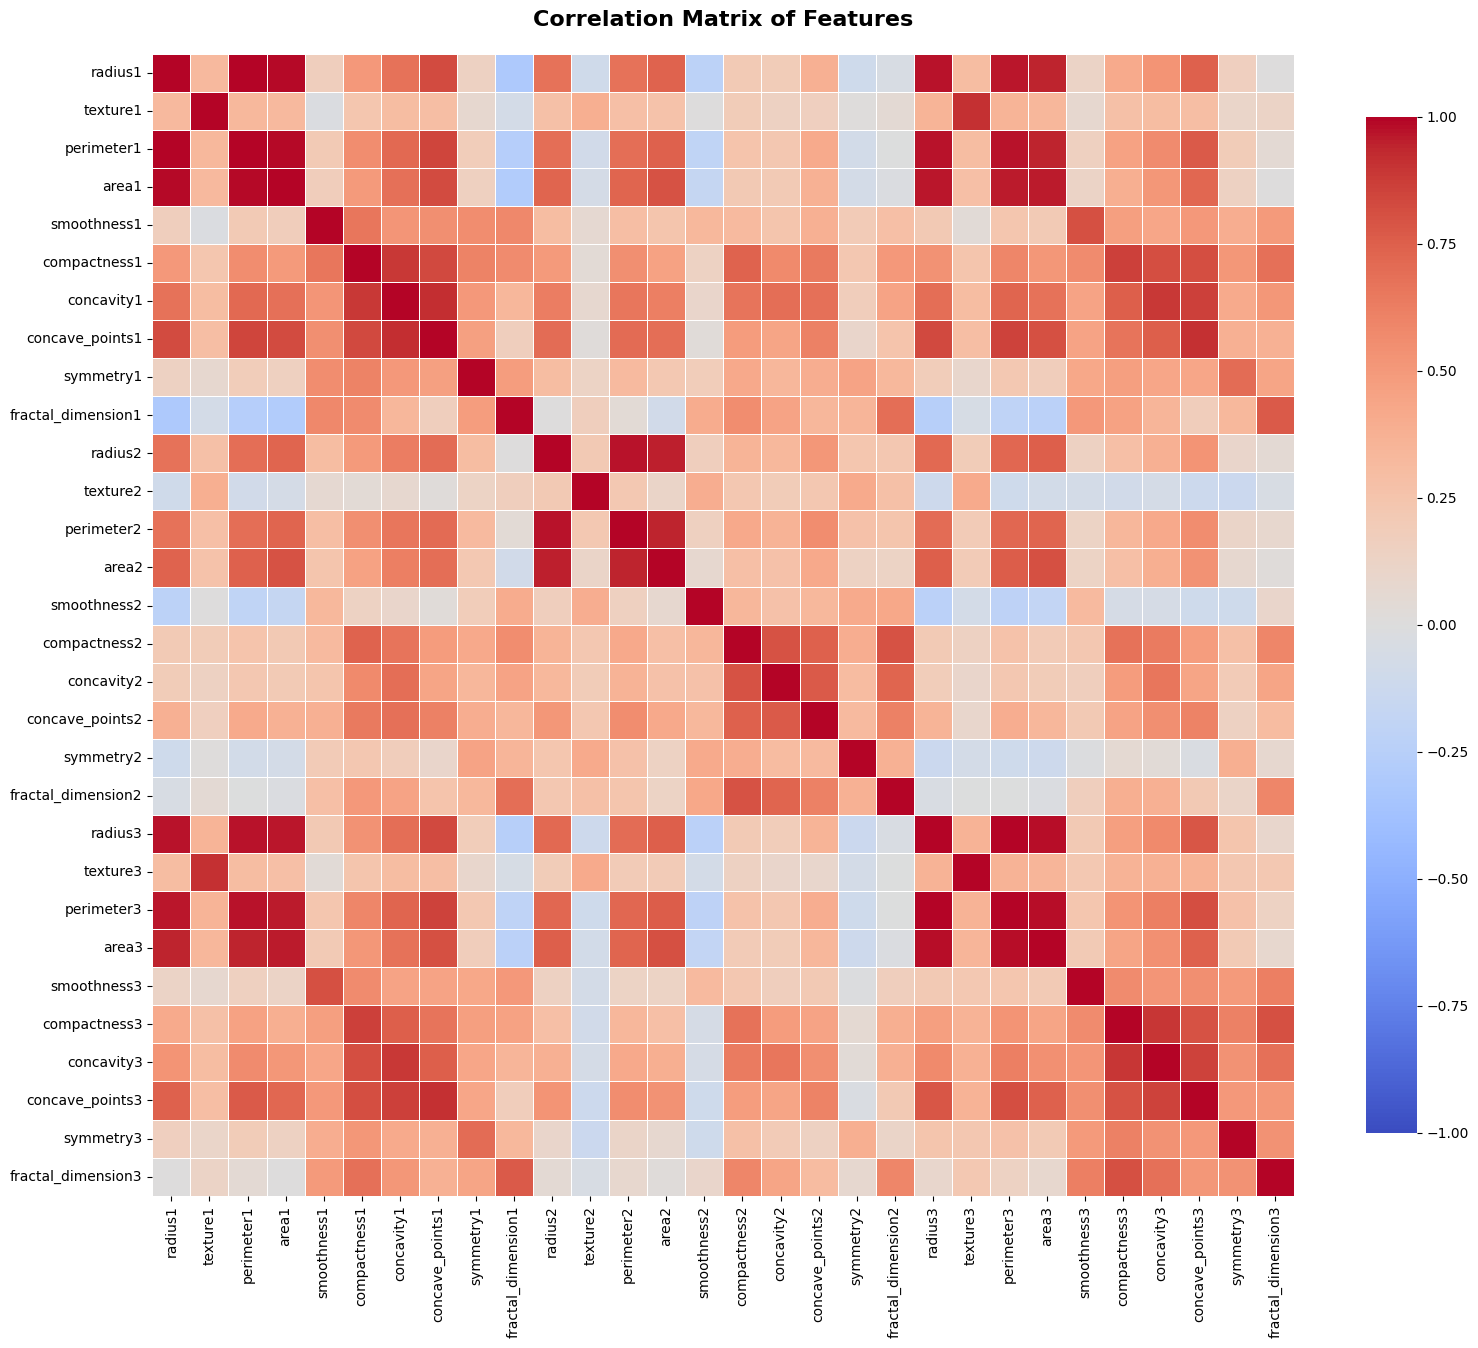


Highly correlated feature pairs (|correlation| > 0.9):
--------------------------------------------------------------------------------
radius1                   <-> perimeter1                :  0.9979
radius3                   <-> perimeter3                :  0.9937
radius1                   <-> area1                     :  0.9874
perimeter1                <-> area1                     :  0.9865
radius3                   <-> area3                     :  0.9840
perimeter3                <-> area3                     :  0.9776
radius2                   <-> perimeter2                :  0.9728
perimeter1                <-> perimeter3                :  0.9704
radius1                   <-> radius3                   :  0.9695
perimeter1                <-> radius3                   :  0.9695
radius1                   <-> perimeter3                :  0.9651
area1                     <-> radius3                   :  0.9627
area1                     <-> area3                     :  0.9592
area1

In [147]:
correlation_matrix = X.corr()

# Create heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1,  # Minimum value of the color scale
    vmax=1,   # Maximum value of the color scale
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix of Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nHighly correlated feature pairs (|correlation| > 0.9):")
print("-" * 80)
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr:
    for feat1, feat2, corr in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{feat1:25s} <-> {feat2:25s} : {corr:7.4f}")
else:
    print("No feature pairs with correlation > 0.9 found.")

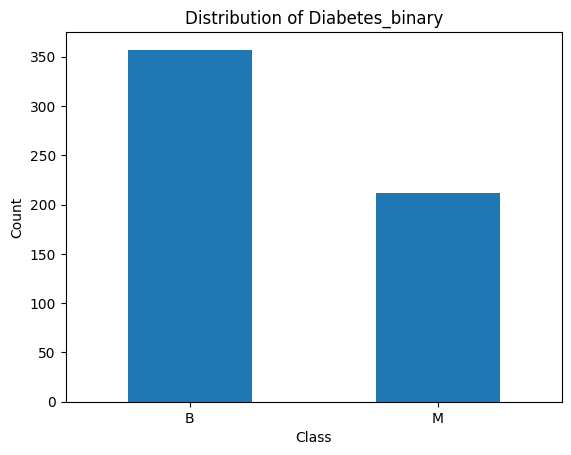

In [148]:
y.squeeze().value_counts().plot(kind="bar")


plt.title("Distribution of Diabetes_binary")
plt.xlabel("Class")
plt.ylabel("Count")

# Optional: Rotate labels if they are overlapping
plt.xticks(rotation=0)

plt.show()

### 1.3. Prepare the data

In [149]:
# Split the dataset into training (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train (first 5 rows):\n{y_train.head()}")

X_train shape: (398, 30)
X_test shape: (171, 30)
y_train (first 5 rows):
    Diagnosis
149         B
124         B
421         B
195         B
545         B


### 2.1. Base Pipeline

In [150]:
# Create a base pipeline with standardization and Logistic Regression
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])


### 2.2. Train the model and evaluate

Training Time: 0.0053 seconds
Training Accuracy: 0.9874
Test Accuracy: 0.9825
CV Mean Accuracy: 0.9748 (+/- 0.0277)

Classification Report (Test Set):
              precision    recall  f1-score   support

           B       0.99      0.98      0.99       108
           M       0.97      0.98      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



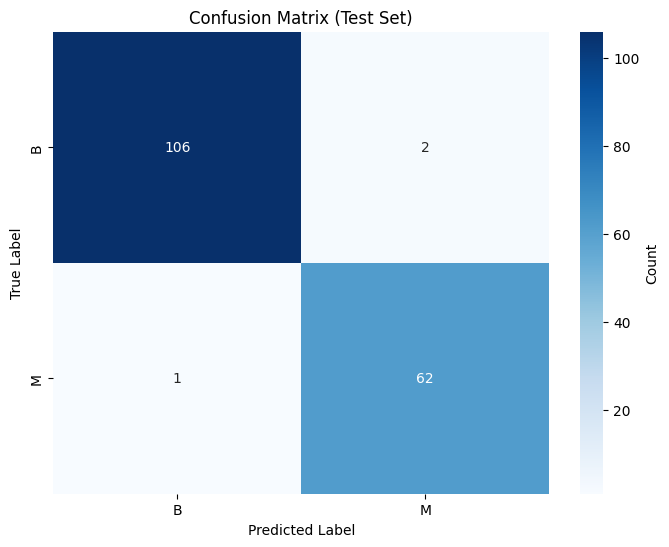

In [151]:
# Flatten targets for sklearn
y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

# Measure training time
start_time = time.time()
base_pipeline.fit(X_train, y_train_flat)
end_time = time.time()
training_time = end_time - start_time

# Predictions
y_pred_train = base_pipeline.predict(X_train)
y_pred_test = base_pipeline.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train_flat, y_pred_train)
test_acc = accuracy_score(y_test_flat, y_pred_test)

# Cross-validation (5-fold)
cv_scores = cross_val_score(base_pipeline, X_train, y_train_flat, cv=5)

print(f"Training Time: {training_time:.4f} seconds")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"CV Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\nClassification Report (Test Set):")
print(classification_report(y_test_flat, y_pred_test))

# Confusion Matrix
cm = confusion_matrix(y_test_flat, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=base_pipeline.named_steps['classifier'].classes_,
    yticklabels=base_pipeline.named_steps['classifier'].classes_,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 2.3. Record the results

In [152]:
# Initialize or append to results dataframe
if 'results_df' not in locals():
    results_df = pd.DataFrame(columns=[
        'Method',
        'Training Time (s)',
        'Training Accuracy',
        'Test Accuracy',
        'CV Mean Accuracy'
    ])

new_result = pd.DataFrame({
    'Method': ['Base Pipeline (Logistic Regression)'],
    'Training Time (s)': [training_time],
    'Training Accuracy': [train_acc],
    'Test Accuracy': [test_acc],
    'CV Mean Accuracy': [cv_scores.mean()]
})

results_df = pd.concat([results_df, new_result], ignore_index=True)
results_df

,Method,Training Time (s),Training Accuracy,Test Accuracy,CV Mean Accuracy
0,Base Pipeline (Logistic Regression),0.006039,0.987437,0.982456,0.974810
1,Base Pipeline (Logistic Regression),0.004488,0.987437,0.982456,0.974810
2,Base Pipeline (Logistic Regression),0.005370,0.987437,0.982456,0.974810
3,Base Pipeline (Logistic Regression),0.004746,0.987437,0.982456,0.974810
4,"KPCA(Poly) [n=10, deg=2, gamma=0.001]",0.763391,0.924623,0.941520,0.914557
5,"KPCA(Poly) [n=10, deg=2, gamma=0.01]",0.116496,0.957286,0.964912,0.949684
6,"KPCA(Poly) [n=10, deg=2, gamma=0.1]",0.177223,0.959799,0.959064,0.944620
7,"KPCA(Poly) [n=10, deg=3, gamma=0.001]",0.653856,0.932161,0.953216,0.924557
8,"KPCA(Poly) [n=10, deg=3, gamma=0.01]",0.117211,0.959799,0.970760,0.947184
9,"KPCA(Poly) [n=10, deg=3, gamma=0.1]",0.980193,0.949749,0.941520,0.942184


### 3.1. Component Analysis

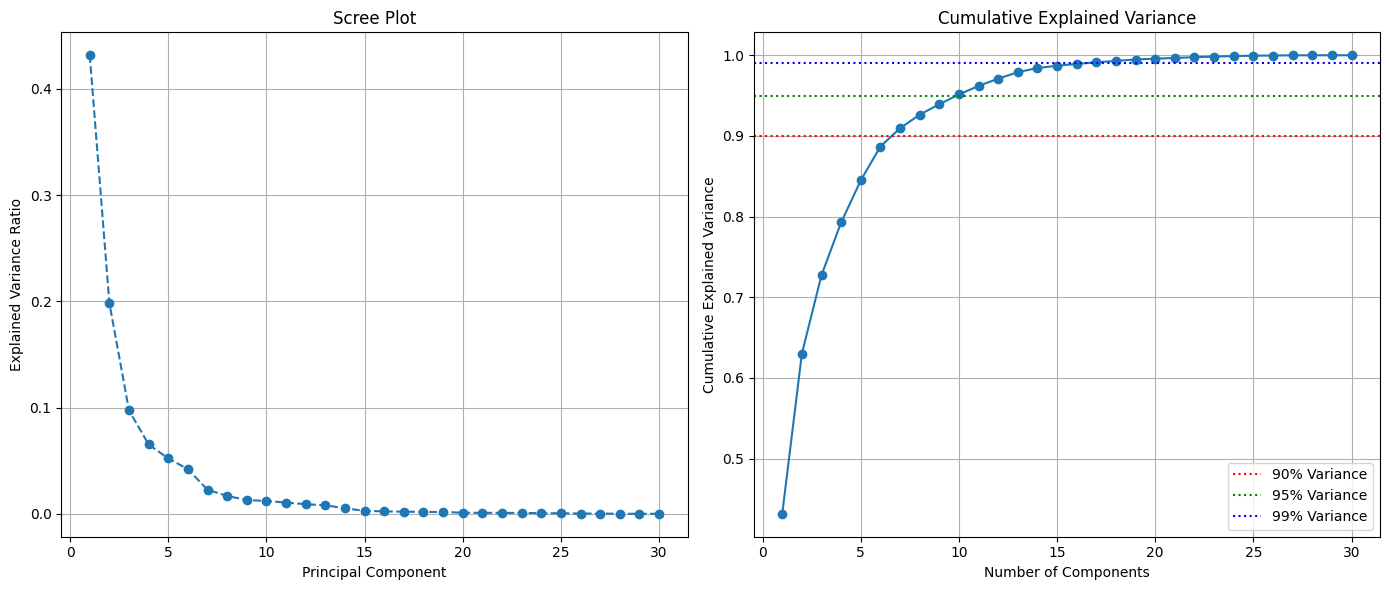

Components needed to explain 90% of variance: 7
Components needed to explain 95% of variance: 10
Components needed to explain 99% of variance: 17


In [153]:
# Standardize the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Create PCA without limiting components
pca = PCA()
pca.fit(X_train_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Scree Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)

# Cumulative Explained Variance Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle=':', label='95% Variance')
plt.axhline(y=0.99, color='b', linestyle=':', label='99% Variance')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Determine components needed for variance thresholds
variance_thresholds = [0.90, 0.95, 0.99]
components_needed = {}

for threshold in variance_thresholds:
    n_components = np.argmax(cumulative_variance_ratio >= threshold) + 1
    components_needed[threshold] = n_components
    print(f"Components needed to explain {int(threshold * 100)}% of variance: {n_components}")

### 3.2. Experiments with different numbers of components

In [154]:
# Define the list of components to test
# Create a mapping for descriptive names
pca_configs = [
    {'n': 2, 'desc': 'Fixed n=2'},
    {'n': 5, 'desc': 'Fixed n=5'},
    {'n': 10, 'desc': 'Fixed n=10'},
    {'n': components_needed[0.90], 'desc': 'Var=90%'},
    {'n': components_needed[0.95], 'desc': 'Var=95%'},
    {'n': components_needed[0.99], 'desc': 'Var=99%'}
]

for config in pca_configs:
    n_components = config['n']
    method_name = f"PCA (n={n_components}, {config['desc']})"
    print(f"\nTesting {method_name}...")

    # Create pipeline
    pca_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components)),
        ('classifier', LogisticRegression(random_state=RANDOM_STATE))
    ])

    # Measure training time
    start_time = time.time()
    pca_pipeline.fit(X_train, y_train_flat)
    end_time = time.time()
    pca_training_time = end_time - start_time

    # Predictions
    y_pred_train_pca = pca_pipeline.predict(X_train)
    y_pred_test_pca = pca_pipeline.predict(X_test)

    # Accuracy
    pca_train_acc = accuracy_score(y_train_flat, y_pred_train_pca)
    pca_test_acc = accuracy_score(y_test_flat, y_pred_test_pca)

    # Cross-validation
    pca_cv_scores = cross_val_score(pca_pipeline, X_train, y_train_flat, cv=5)

    # Print results
    print(f"Training Time: {pca_training_time:.4f} seconds")
    print(f"Training Accuracy: {pca_train_acc:.4f}")
    print(f"Test Accuracy: {pca_test_acc:.4f}")
    print(f"CV Mean Accuracy: {pca_cv_scores.mean():.4f} (+/- {pca_cv_scores.std() * 2:.4f})")

    # Avoid duplicates: remove previous result with same Method name if exists
    if 'results_df' in locals():
        results_df = results_df[results_df['Method'] != method_name]

    # Record results
    new_result = pd.DataFrame({
        'Method': [method_name],
        'Training Time (s)': [pca_training_time],
        'Training Accuracy': [pca_train_acc],
        'Test Accuracy': [pca_test_acc],
        'CV Mean Accuracy': [pca_cv_scores.mean()]
    })
    results_df = pd.concat([results_df, new_result], ignore_index=True)
results_df


Testing PCA (n=2, Fixed n=2)...
Training Time: 0.0046 seconds
Training Accuracy: 0.9472
Test Accuracy: 0.9766
CV Mean Accuracy: 0.9422 (+/- 0.0200)

Testing PCA (n=5, Fixed n=5)...
Training Time: 0.0038 seconds
Training Accuracy: 0.9724
Test Accuracy: 0.9883
CV Mean Accuracy: 0.9648 (+/- 0.0188)

Testing PCA (n=10, Fixed n=10)...
Training Time: 0.0042 seconds
Training Accuracy: 0.9799
Test Accuracy: 0.9942
CV Mean Accuracy: 0.9648 (+/- 0.0332)

Testing PCA (n=7, Var=90%)...
Training Time: 0.0040 seconds
Training Accuracy: 0.9749
Test Accuracy: 0.9883
CV Mean Accuracy: 0.9648 (+/- 0.0485)

Testing PCA (n=10, Var=95%)...
Training Time: 0.0042 seconds
Training Accuracy: 0.9799
Test Accuracy: 0.9942
CV Mean Accuracy: 0.9648 (+/- 0.0332)

Testing PCA (n=17, Var=99%)...
Training Time: 0.0052 seconds
Training Accuracy: 0.9849
Test Accuracy: 0.9883
CV Mean Accuracy: 0.9748 (+/- 0.0277)


,Method,Training Time (s),Training Accuracy,Test Accuracy,CV Mean Accuracy
0,Base Pipeline (Logistic Regression),0.006039,0.987437,0.982456,0.974810
1,Base Pipeline (Logistic Regression),0.004488,0.987437,0.982456,0.974810
2,Base Pipeline (Logistic Regression),0.005370,0.987437,0.982456,0.974810
3,Base Pipeline (Logistic Regression),0.004746,0.987437,0.982456,0.974810
4,"KPCA(Poly) [n=10, deg=2, gamma=0.001]",0.763391,0.924623,0.941520,0.914557
5,"KPCA(Poly) [n=10, deg=2, gamma=0.01]",0.116496,0.957286,0.964912,0.949684
6,"KPCA(Poly) [n=10, deg=2, gamma=0.1]",0.177223,0.959799,0.959064,0.944620
7,"KPCA(Poly) [n=10, deg=3, gamma=0.001]",0.653856,0.932161,0.953216,0.924557
8,"KPCA(Poly) [n=10, deg=3, gamma=0.01]",0.117211,0.959799,0.970760,0.947184
9,"KPCA(Poly) [n=10, deg=3, gamma=0.1]",0.980193,0.949749,0.941520,0.942184


### 3.3. Visualization (n_components=2)

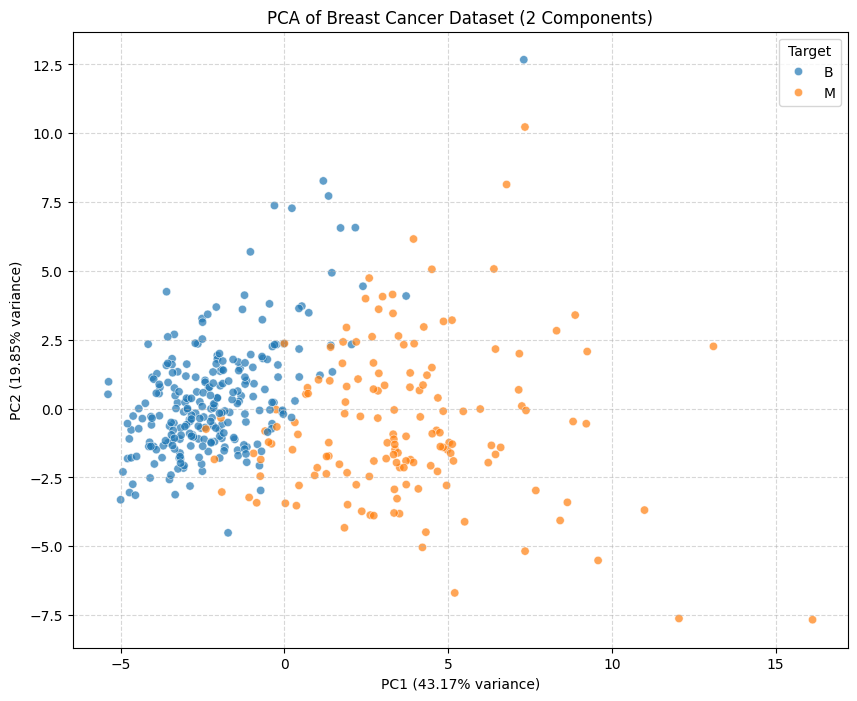

In [155]:
# Transform data to 2 components
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame(data=X_train_pca_2d, columns=['PC1', 'PC2'])
pca_df['Target'] = y_train_flat

# Explained variance
var_explained = pca_2d.explained_variance_ratio_

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df, alpha=0.7)

plt.xlabel(f'PC1 ({var_explained[0]:.2%} variance)')
plt.ylabel(f'PC2 ({var_explained[1]:.2%} variance)')
plt.title('PCA of Breast Cancer Dataset (2 Components)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Observation:**
The scatter plot shows that the two classes (Benign and Malignant) are reasonably well-separated in the 2D principal component space, although there is some overlap in the center. PC1 alone seems to capture a significant portion of the variance that discriminates between the two classes. This suggests that a linear classifier like Logistic Regression should perform well even with just these two components.

### 3.4. Comparison Table

In [156]:
# Display the comparison table
print("Final Comparison Table:")
results_df

Final Comparison Table:


,Method,Training Time (s),Training Accuracy,Test Accuracy,CV Mean Accuracy
0,Base Pipeline (Logistic Regression),0.006039,0.987437,0.982456,0.974810
1,Base Pipeline (Logistic Regression),0.004488,0.987437,0.982456,0.974810
2,Base Pipeline (Logistic Regression),0.005370,0.987437,0.982456,0.974810
3,Base Pipeline (Logistic Regression),0.004746,0.987437,0.982456,0.974810
4,"KPCA(Poly) [n=10, deg=2, gamma=0.001]",0.763391,0.924623,0.941520,0.914557
5,"KPCA(Poly) [n=10, deg=2, gamma=0.01]",0.116496,0.957286,0.964912,0.949684
6,"KPCA(Poly) [n=10, deg=2, gamma=0.1]",0.177223,0.959799,0.959064,0.944620
7,"KPCA(Poly) [n=10, deg=3, gamma=0.001]",0.653856,0.932161,0.953216,0.924557
8,"KPCA(Poly) [n=10, deg=3, gamma=0.01]",0.117211,0.959799,0.970760,0.947184
9,"KPCA(Poly) [n=10, deg=3, gamma=0.1]",0.980193,0.949749,0.941520,0.942184


### 4.1. Kernel PCA (RBF)

In [157]:
# RBF Kernel PCA parameters
kpca_components = [2, 5, 10]
gamma_values = [0.001, 0.01, 0.1]

print("Testing Kernel PCA (RBF)...")

for n_comp in kpca_components:
    for gamma in gamma_values:
        method_name = f"KPCA(RBF) [n={n_comp}, gamma={gamma}]"
        print(f"\nTesting {method_name}...")

        # Create pipeline
        kpca_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('kpca', KernelPCA(n_components=n_comp, kernel='rbf', gamma=gamma, random_state=RANDOM_STATE)),
            ('classifier', LogisticRegression(random_state=RANDOM_STATE))
        ])

        # Measure training time
        start_time = time.time()
        kpca_pipeline.fit(X_train, y_train_flat)
        end_time = time.time()
        kpca_training_time = end_time - start_time

        # Predictions
        y_pred_train_kpca = kpca_pipeline.predict(X_train)
        y_pred_test_kpca = kpca_pipeline.predict(X_test)

        # Accuracy
        kpca_train_acc = accuracy_score(y_train_flat, y_pred_train_kpca)
        kpca_test_acc = accuracy_score(y_test_flat, y_pred_test_kpca)

        # Cross-validation
        kpca_cv_scores = cross_val_score(kpca_pipeline, X_train, y_train_flat, cv=5)

        # Print results
        print(f"Training Time: {kpca_training_time:.4f} seconds")
        print(f"Training Accuracy: {kpca_train_acc:.4f}")
        print(f"Test Accuracy: {kpca_test_acc:.4f}")
        print(f"CV Mean Accuracy: {kpca_cv_scores.mean():.4f} (+/- {kpca_cv_scores.std() * 2:.4f})")

        # Avoid duplicates
        if 'results_df' in locals():
            results_df = results_df[results_df['Method'] != method_name]

        # Record results
        new_result = pd.DataFrame({
            'Method': [method_name],
            'Training Time (s)': [kpca_training_time],
            'Training Accuracy': [kpca_train_acc],
            'Test Accuracy': [kpca_test_acc],
            'CV Mean Accuracy': [kpca_cv_scores.mean()]
        })
        results_df = pd.concat([results_df, new_result], ignore_index=True)

Testing Kernel PCA (RBF)...

Testing KPCA(RBF) [n=2, gamma=0.001]...
Training Time: 0.0302 seconds
Training Accuracy: 0.9095
Test Accuracy: 0.9240
CV Mean Accuracy: 0.9045 (+/- 0.0255)

Testing KPCA(RBF) [n=2, gamma=0.01]...
Training Time: 0.0337 seconds
Training Accuracy: 0.9347
Test Accuracy: 0.9357
CV Mean Accuracy: 0.9246 (+/- 0.0278)

Testing KPCA(RBF) [n=2, gamma=0.1]...
Training Time: 0.0346 seconds
Training Accuracy: 0.8693
Test Accuracy: 0.8246
CV Mean Accuracy: 0.8668 (+/- 0.0406)

Testing KPCA(RBF) [n=5, gamma=0.001]...
Training Time: 0.0863 seconds
Training Accuracy: 0.9221
Test Accuracy: 0.9415
CV Mean Accuracy: 0.9146 (+/- 0.0191)

Testing KPCA(RBF) [n=5, gamma=0.01]...
Training Time: 0.0307 seconds
Training Accuracy: 0.9497
Test Accuracy: 0.9591
CV Mean Accuracy: 0.9447 (+/- 0.0130)

Testing KPCA(RBF) [n=5, gamma=0.1]...
Training Time: 0.0354 seconds
Training Accuracy: 0.9121
Test Accuracy: 0.9064
CV Mean Accuracy: 0.9046 (+/- 0.0335)

Testing KPCA(RBF) [n=10, gamma=0.00

### 4.2. Kernel PCA (Polynomial)

In [158]:
# Polynomial Kernel PCA parameters
degrees = [2, 3]

print("Testing Kernel PCA (Polynomial)...")

for n_comp in kpca_components:
    for degree in degrees:
        for gamma in gamma_values:
            method_name = f"KPCA(Poly) [n={n_comp}, deg={degree}, gamma={gamma}]"
            print(f"\nTesting {method_name}...")

            # Create pipeline
            kpca_poly_pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('kpca', KernelPCA(n_components=n_comp, kernel='poly', degree=degree, gamma=gamma, coef0=1,
                                   random_state=RANDOM_STATE)),
                ('classifier', LogisticRegression(random_state=RANDOM_STATE))
            ])

            # Measure training time
            start_time = time.time()
            kpca_poly_pipeline.fit(X_train, y_train_flat)
            end_time = time.time()
            kpca_training_time = end_time - start_time

            # Predictions
            y_pred_train_poly = kpca_poly_pipeline.predict(X_train)
            y_pred_test_poly = kpca_poly_pipeline.predict(X_test)

            # Accuracy
            poly_train_acc = accuracy_score(y_train_flat, y_pred_train_poly)
            poly_test_acc = accuracy_score(y_test_flat, y_pred_test_poly)

            # Cross-validation
            poly_cv_scores = cross_val_score(kpca_poly_pipeline, X_train, y_train_flat, cv=5)

            # Print results
            print(f"Training Time: {kpca_training_time:.4f} seconds")
            print(f"Training Accuracy: {poly_train_acc:.4f}")
            print(f"Test Accuracy: {poly_test_acc:.4f}")
            print(f"CV Mean Accuracy: {poly_cv_scores.mean():.4f} (+/- {poly_cv_scores.std() * 2:.4f})")

            # Avoid duplicates
            if 'results_df' in locals():
                results_df = results_df[results_df['Method'] != method_name]

            # Record results
            new_result = pd.DataFrame({
                'Method': [method_name],
                'Training Time (s)': [kpca_training_time],
                'Training Accuracy': [poly_train_acc],
                'Test Accuracy': [poly_test_acc],
                'CV Mean Accuracy': [poly_cv_scores.mean()]
            })
            results_df = pd.concat([results_df, new_result], ignore_index=True)

Testing Kernel PCA (Polynomial)...

Testing KPCA(Poly) [n=2, deg=2, gamma=0.001]...
Training Time: 0.0702 seconds
Training Accuracy: 0.9070
Test Accuracy: 0.9240
CV Mean Accuracy: 0.9045 (+/- 0.0255)

Testing KPCA(Poly) [n=2, deg=2, gamma=0.01]...
Training Time: 0.0592 seconds
Training Accuracy: 0.9296
Test Accuracy: 0.9415
CV Mean Accuracy: 0.9246 (+/- 0.0323)

Testing KPCA(Poly) [n=2, deg=2, gamma=0.1]...
Training Time: 0.0316 seconds
Training Accuracy: 0.8467
Test Accuracy: 0.8363
CV Mean Accuracy: 0.8568 (+/- 0.0537)

Testing KPCA(Poly) [n=2, deg=3, gamma=0.001]...
Training Time: 0.0469 seconds
Training Accuracy: 0.9121
Test Accuracy: 0.9240
CV Mean Accuracy: 0.9145 (+/- 0.0298)

Testing KPCA(Poly) [n=2, deg=3, gamma=0.01]...
Training Time: 0.0562 seconds
Training Accuracy: 0.9146
Test Accuracy: 0.9357
CV Mean Accuracy: 0.9121 (+/- 0.0416)

Testing KPCA(Poly) [n=2, deg=3, gamma=0.1]...
Training Time: 0.0745 seconds
Training Accuracy: 0.8744
Test Accuracy: 0.9006
CV Mean Accuracy: 0

### 4.3. Factor Analysis

In [159]:
from sklearn.decomposition import FactorAnalysis

fa_components = [2, 5, 10]

print("Testing Factor Analysis...")

for n_comp in fa_components:
    method_name = f"Factor Analysis [n={n_comp}]"
    print(f"\nTesting {method_name}...")

    # Create pipeline
    fa_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('fa', FactorAnalysis(n_components=n_comp, random_state=RANDOM_STATE)),
        ('classifier', LogisticRegression(random_state=RANDOM_STATE))
    ])

    # Measure training time
    start_time = time.time()
    fa_pipeline.fit(X_train, y_train_flat)
    end_time = time.time()
    fa_training_time = end_time - start_time

    # Predictions
    y_pred_train_fa = fa_pipeline.predict(X_train)
    y_pred_test_fa = fa_pipeline.predict(X_test)

    # Accuracy
    fa_train_acc = accuracy_score(y_train_flat, y_pred_train_fa)
    fa_test_acc = accuracy_score(y_test_flat, y_pred_test_fa)

    # Cross-validation
    fa_cv_scores = cross_val_score(fa_pipeline, X_train, y_train_flat, cv=5)

    # Print results
    print(f"Training Time: {fa_training_time:.4f} seconds")
    print(f"Training Accuracy: {fa_train_acc:.4f}")
    print(f"Test Accuracy: {fa_test_acc:.4f}")
    print(f"CV Mean Accuracy: {fa_cv_scores.mean():.4f} (+/- {fa_cv_scores.std() * 2:.4f})")

    # Avoid duplicates
    if 'results_df' in locals():
        results_df = results_df[results_df['Method'] != method_name]

    # Record results
    new_result = pd.DataFrame({
        'Method': [method_name],
        'Training Time (s)': [fa_training_time],
        'Training Accuracy': [fa_train_acc],
        'Test Accuracy': [fa_test_acc],
        'CV Mean Accuracy': [fa_cv_scores.mean()]
    })
    results_df = pd.concat([results_df, new_result], ignore_index=True)

# Factor Loadings Visualization (for n=2 only, or first 2 factors of larger models)
fa = FactorAnalysis(n_components=2, random_state=RANDOM_STATE)
fa.fit(X_train_scaled)

# Print top features for each factor
for i in range(2):
    print(f"\nTop features for Factor {i + 1}:")
    # Get absolute values of loadings
    abs_loadings = np.abs(fa.components_[i])
    # Sort indices
    sorted_indices = np.argsort(abs_loadings)[::-1]
    # Print top 5
    for idx in sorted_indices[:5]:
        print(f"{X.columns[idx]}: {fa.components_[i][idx]:.4f}")

Testing Factor Analysis...

Testing Factor Analysis [n=2]...
Training Time: 0.0853 seconds
Training Accuracy: 0.9095
Test Accuracy: 0.9357
CV Mean Accuracy: 0.9070 (+/- 0.0259)

Testing Factor Analysis [n=5]...
Training Time: 0.6637 seconds
Training Accuracy: 0.9623
Test Accuracy: 0.9708
CV Mean Accuracy: 0.9547 (+/- 0.0307)

Testing Factor Analysis [n=10]...
Training Time: 0.8238 seconds
Training Accuracy: 0.9824
Test Accuracy: 0.9708
CV Mean Accuracy: 0.9698 (+/- 0.0515)

Top features for Factor 1:
perimeter1: 0.9995
radius1: 0.9992
area1: 0.9869
radius3: 0.9692
perimeter3: 0.9683

Top features for Factor 2:
compactness1: 0.8392
fractal_dimension1: 0.8370
fractal_dimension3: 0.8354
compactness3: 0.7716
compactness2: 0.7479


**Interpretation of Factors:**

*   **Factor 1**: High loadings on features like `perimeter1`, `radius1`, `area1`, `radius3`, and `perimeter3`. This factor clearly represents the overall **size** of the cell nuclei.
*   **Factor 2**: High loadings on `compactness`, `fractal_dimension` (both mean and worst). This factor appears to capture **shape complexity and irregularity** characteristics that are somewhat independent of the pure size.

### 5.1. Final Comparison

In [160]:
# Final cleanup and display of the results table
if 'results_df' in locals():
    # Sort by Test Accuracy descending
    final_results = results_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

    # Display the comprehensive table
    print("Comprehensive Comparison Table (Sorted by Test Accuracy):")
    display(final_results)

    # Highlight the best model
    best_model = final_results.iloc[0]
    print(f"\nBest Model based on Test Accuracy: {best_model['Method']}")
    print(f"Test Accuracy: {best_model['Test Accuracy']:.4f}")
    print(f"Training Time: {best_model['Training Time (s)']:.4f} s")
else:
    print("No results to display.")

Comprehensive Comparison Table (Sorted by Test Accuracy):


,Method,Training Time (s),Training Accuracy,Test Accuracy,CV Mean Accuracy
0,"PCA (n=10, Fixed n=10)",0.004235,0.979899,0.994152,0.964810
1,"PCA (n=10, Var=95%)",0.004226,0.979899,0.994152,0.964810
2,"PCA (n=7, Var=90%)",0.004027,0.974874,0.988304,0.964810
3,"PCA (n=5, Fixed n=5)",0.003833,0.972362,0.988304,0.964810
4,"PCA (n=17, Var=99%)",0.005237,0.984925,0.988304,0.974810
5,Base Pipeline (Logistic Regression),0.006039,0.987437,0.982456,0.974810
6,Base Pipeline (Logistic Regression),0.005332,0.987437,0.982456,0.974810
7,Base Pipeline (Logistic Regression),0.004524,0.987437,0.982456,0.974810
8,Base Pipeline (Logistic Regression),0.004488,0.987437,0.982456,0.974810
9,Base Pipeline (Logistic Regression),0.005370,0.987437,0.982456,0.974810



Best Model based on Test Accuracy: PCA (n=10, Fixed n=10)
Test Accuracy: 0.9942
Training Time: 0.0042 s


### 5.2. Comparative Visualizations


/tmp/ipykernel_287759/2966122588.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


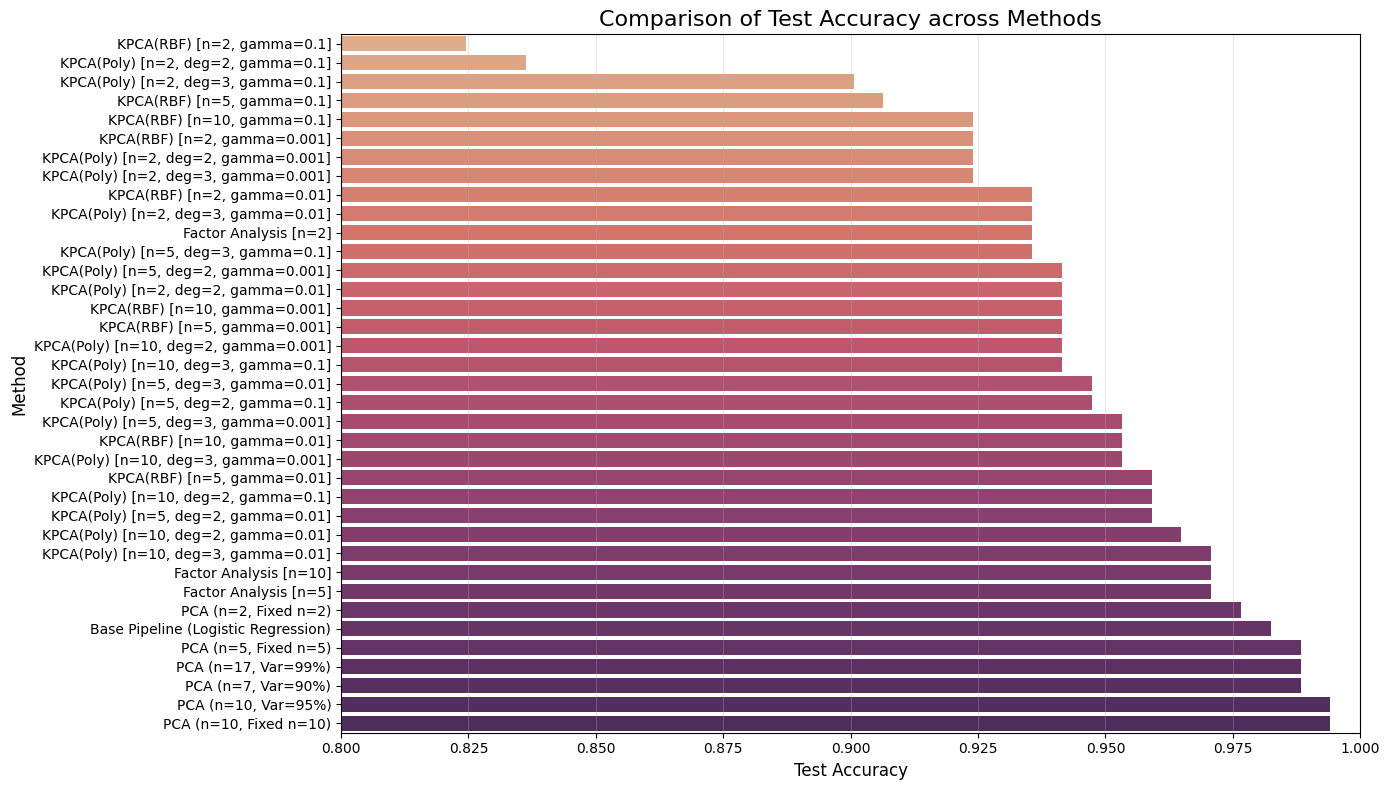

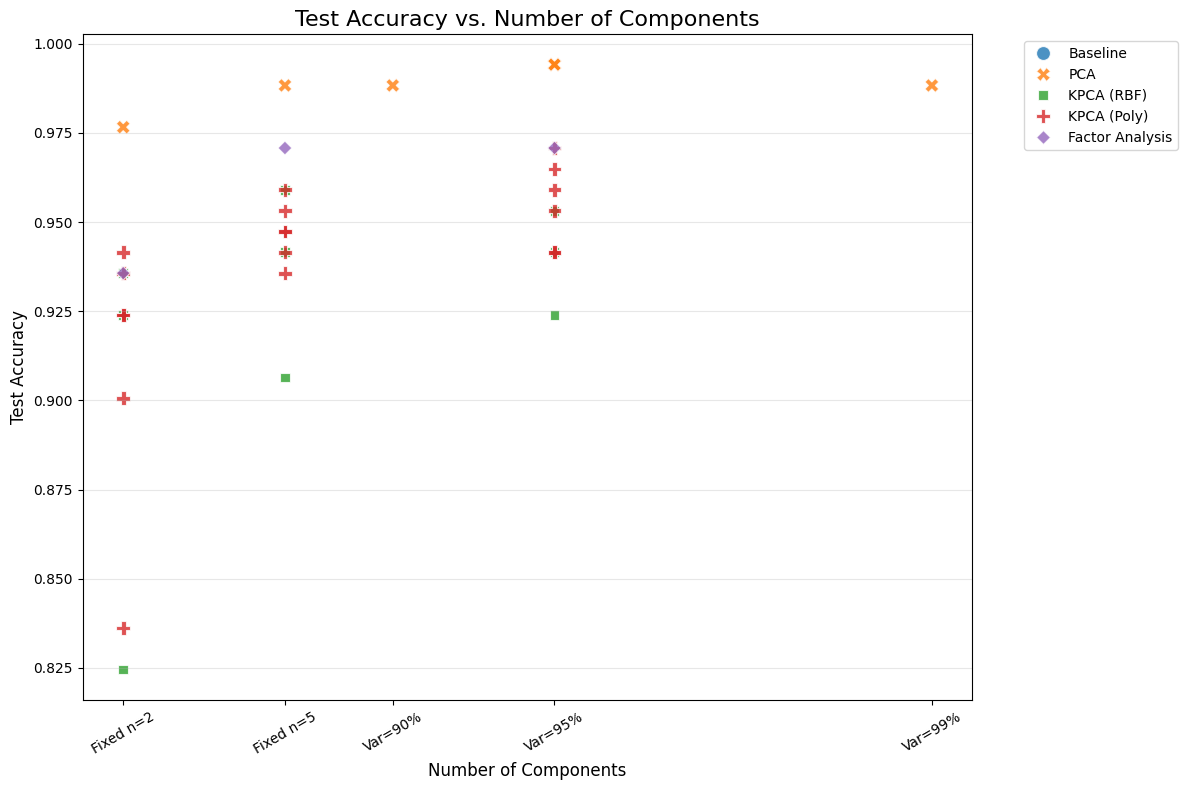

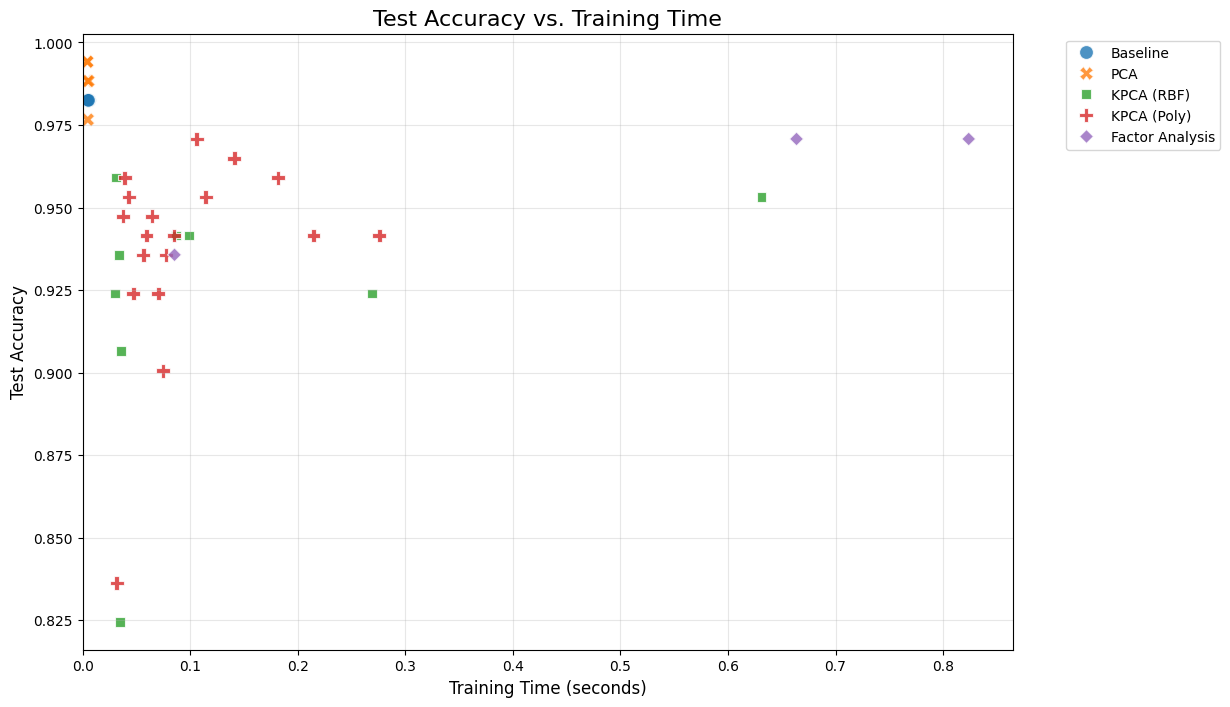

In [161]:
def extract_n_components(method_str):
    match = re.search(r'n=(\d+)', method_str)
    if match:
        return int(match.group(1))
    return None


if 'results_df' in locals() and not results_df.empty:
    # Create a copy to avoid SettingWithCopyWarning
    plot_df = results_df.copy()
    plot_df['n_components'] = plot_df['Method'].apply(extract_n_components)


    # Extract base method name (e.g., PCA, KPCA(RBF), KPCA(Poly)) for coloring
    def extract_base_method(method_str):
        if 'KPCA(RBF)' in method_str:
            return 'KPCA (RBF)'
        elif 'KPCA(Poly)' in method_str:
            return 'KPCA (Poly)'
        elif 'PCA' in method_str:
            return 'PCA'
        elif 'Factor Analysis' in method_str:
            return 'Factor Analysis'
        else:
            return 'Baseline'


    plot_df['Base Method'] = plot_df['Method'].apply(extract_base_method)

    # 1. Bar chart of Test Accuracy
    plt.figure(figsize=(14, 8))
    # Sort by test accuracy
    plot_df_sorted = plot_df.sort_values('Test Accuracy', ascending=True)

    sns.barplot(
        x='Test Accuracy',
        y='Method',
        data=plot_df_sorted,
        palette='flare'
    )

    plt.title('Comparison of Test Accuracy across Methods', fontsize=16)
    plt.xlabel('Test Accuracy', fontsize=12)
    plt.ylabel('Method', fontsize=12)
    plt.xlim(0.8, 1.0)  # Zoom in on high accuracy range
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 2. Scatter plot: Test Accuracy vs. Number of Components
    n_to_label = {cfg['n']: cfg['desc'] for cfg in pca_configs}
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=plot_df,
        x='n_components',
        y='Test Accuracy',
        hue='Base Method',
        style='Base Method',
        s=100,
        alpha=0.8
    )
    unique_ns = sorted(plot_df['n_components'].unique())
    plt.xticks(
        ticks=unique_ns,
        labels=[n_to_label.get(n, str(n)) for n in unique_ns],
        rotation=30
    )
    plt.title('Test Accuracy vs. Number of Components', fontsize=16)
    plt.xlabel('Number of Components', fontsize=12)
    plt.ylabel('Test Accuracy', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 3. Scatter plot: Test Accuracy vs. Training Time
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=plot_df,
        x='Training Time (s)',
        y='Test Accuracy',
        hue='Base Method',
        style='Base Method',
        s=100,
        alpha=0.8
    )
    plt.title('Test Accuracy vs. Training Time', fontsize=16)
    plt.xlabel('Training Time (seconds)', fontsize=12)
    plt.ylabel('Test Accuracy', fontsize=12)
    plt.grid(True, alpha=0.3, which="both", ls="-")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(left=0)
    plt.show()
else:
    print("No results available for visualization.")

### 5.3. Trade-off Analysis

In [162]:


if 'results_df' in locals() and not results_df.empty:
    # 1. Best Accuracy
    best_acc_idx = results_df['Test Accuracy'].idxmax()
    best_acc_model = results_df.loc[best_acc_idx]
    print("1. Model with Best Accuracy on Test Set:")
    print(f"   Method: {best_acc_model['Method']}")
    print(f"   Test Accuracy: {best_acc_model['Test Accuracy']:.4f}")

    # 2. Fastest Training Time
    fastest_idx = results_df['Training Time (s)'].idxmin()
    fastest_model = results_df.loc[fastest_idx]
    print("\n2. Model with Fastest Training Time:")
    print(f"   Method: {fastest_model['Method']}")
    print(f"   Training Time: {fastest_model['Training Time (s)']:.4f} s")

    # 3. Best Trade-off
    # Definition: Among models with test accuracy within 1% of the best model, find the fastest one.
    threshold = best_acc_model['Test Accuracy'] - 0.01
    top_models = results_df[results_df['Test Accuracy'] >= threshold]
    best_tradeoff_idx = top_models['Training Time (s)'].idxmin()
    best_tradeoff_model = top_models.loc[best_tradeoff_idx]

    print("\n3. Model with Best Trade-off (Fastest among top 1% accuracy models):")
    print(f"   Method: {best_tradeoff_model['Method']}")
    print(f"   Test Accuracy: {best_tradeoff_model['Test Accuracy']:.4f}")
    print(f"   Training Time: {best_tradeoff_model['Training Time (s)']:.4f} s")

    # 4. Impact of Dimensionality Reduction
    # Get baseline model
    baseline = results_df[results_df['Method'] == 'Base Pipeline (Logistic Regression)'].iloc[0]

    print("\n4. Impact of Dimensionality Reduction vs Baseline:")
    print(f"   Baseline Accuracy: {baseline['Test Accuracy']:.4f}")

    diff = best_tradeoff_model['Test Accuracy'] - baseline['Test Accuracy']
    if diff > 0.001:
        impact = "Improved"
    elif diff < -0.001:
        impact = "Worsened"
    else:
        impact = "Unchanged (or very similar)"

    print(f"   Best Trade-off Model Accuracy: {best_tradeoff_model['Test Accuracy']:.4f}")
    print(f"   Result: {impact} accuracy by {abs(diff):.4f}")
    print(
        f"   Speedup: {baseline['Training Time (s)'] / best_tradeoff_model['Training Time (s)']:.2f}x faster than baseline")
else:
    print("No results available for analysis.")

1. Model with Best Accuracy on Test Set:
   Method: PCA (n=10, Fixed n=10)
   Test Accuracy: 0.9942

2. Model with Fastest Training Time:
   Method: PCA (n=5, Fixed n=5)
   Training Time: 0.0038 s

3. Model with Best Trade-off (Fastest among top 1% accuracy models):
   Method: PCA (n=5, Fixed n=5)
   Test Accuracy: 0.9883
   Training Time: 0.0038 s

4. Impact of Dimensionality Reduction vs Baseline:
   Baseline Accuracy: 0.9825
   Best Trade-off Model Accuracy: 0.9883
   Result: Improved accuracy by 0.0058
   Speedup: 1.58x faster than baseline
